In [1]:
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

In [2]:
import gym
import veins_gym

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
import os, subprocess, shutil, sys, pathlib

def source_bash_env(script_path: str):
    cmd = f"bash -lc 'source {script_path} && env -0'"
    out = subprocess.check_output(cmd, shell=True)
    for chunk in out.split(b'\x00'):
        if not chunk: continue
        k, _, v = chunk.partition(b'=')
        if k: os.environ[k.decode()] = v.decode()

omnetpp_setenv = "/home/rohith-v/Rohith/MP/omnetpp-5.7.1-src-linux/omnetpp-5.7.1/setenv"
if os.path.exists(omnetpp_setenv):
    source_bash_env(omnetpp_setenv)
    print('Sourced:', omnetpp_setenv)
else:
    raise FileNotFoundError(f'OMNeT++ setenv not found at {omnetpp_setenv}. Update the path if installed elsewhere.')

print('opp_run path:', shutil.which('opp_run'))
try:
    ver = subprocess.run(['opp_run', '-v'], check=False, capture_output=True, text=True).stdout.splitlines()[0]
    print(ver)
except Exception as e:
    print('Warning: opp_run not callable:', e)

base = pathlib.Path.cwd()
sc_dir = (base / '..' / 'scenario').resolve()
print('scenario dir:', sc_dir)
print('omnetpp.ini exists:', (sc_dir / 'omnetpp.ini').exists())
print('run script exists:', (sc_dir / 'run').exists())
print('sumo path:', shutil.which('sumo'))

Sourced: /home/rohith-v/Rohith/MP/omnetpp-5.7.1-src-linux/omnetpp-5.7.1/setenv
opp_run path: /home/rohith-v/Rohith/MP/omnetpp-5.7.1-src-linux/omnetpp-5.7.1/bin/opp_run
OMNeT++ Discrete Event Simulation  (C) 1992-2021 Andras Varga, OpenSim Ltd.
scenario dir: /home/rohith-v/Rohith/MP/vanet_task_offloading/scenario
omnetpp.ini exists: True
run script exists: True
sumo path: /usr/bin/sumo


In [4]:
import os, pathlib, subprocess, shutil
base = pathlib.Path.cwd()
sc_dir = (base / '..' / 'scenario').resolve()
assert (sc_dir / 'omnetpp.ini').exists(), 'Missing scenario/omnetpp.ini'
gym.register(
    id='veins-straight-v1',
    entry_point='veins_gym:VeinsEnv',
    kwargs={
        'scenario_dir': '../scenario',
        'timeout': 7.0,
        'print_veins_stdout': True,
        'user_interface': 'Cmdenv',
        'config': 'StraightRoad',
        # "run_veins": False, 
		# "port": 5555, 
    },
)
print('Registered veins-straight-v1 with scenario_dir:', sc_dir)

Registered veins-straight-v1 with scenario_dir: /home/rohith-v/Rohith/MP/vanet_task_offloading/scenario


In [5]:
env = gym.make('veins-straight-v1')

## Random Agent

In [6]:
obs = env.reset()

headers = [
    "speed(m/s)", "d0(m)", "d1(m)", "d2(m)", "taskSize(MB)",
    "rsu0Busy", "rsu1Busy", "rsu2Busy", "ul0(Mbps)", "ul1(Mbps)", "ul2(Mbps)",
    "battery", "E_local(J)", "E_offload(J)"
]

def print_obs(step, obs_vec):
    vals = [float(x) for x in np.asarray(obs_vec).tolist()]
    # Handle both 11D and 14D observations
    if len(vals) < 14:
        vals.extend([0.0] * (14 - len(vals)))
    print(f"Step:{step}")
    print("  " + " ".join(f"{h:>13}" for h in headers))
    print("  " + " ".join(f"{v:>13.2f}" for v in vals[:14]))
    print()

done = False
rewards = []
actions_taken = []
steps = 0
while not done:
    action = env.action_space.sample()
    prev_obs = obs
    obs, reward, done, info = env.step(action)
    if float(obs[4]) >= 10.0:
        print_obs(steps, prev_obs)
        print(f"Action taken at step {steps}: {action} ({'local' if action==0 else f'RSU{action-1}'})")
        print(f"Received reward: {round(float(reward), 4)}")
        rewards.append(float(reward))
        actions_taken.append(action)
    steps += 1

print('\n=== Random Agent Summary ===')
print(f'Number of steps: {steps}')
print(f'Tasks completed: {len(rewards)}')
print(f'Mean reward: {float(np.mean(rewards)) if rewards else 0.0:.6f}')
if actions_taken:
    print(f'Local executions: {actions_taken.count(0)} ({100*actions_taken.count(0)/len(actions_taken):.1f}%)')
    print(f'Offload decisions: {len(actions_taken) - actions_taken.count(0)} ({100*(len(actions_taken)-actions_taken.count(0))/len(actions_taken):.1f}%)')


/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:181: UserWarning: WARN: The default seed argument in `Env.reset` should be `None`, otherwise the environment will by default always be deterministic. Actual default: seed='NO SEED GIVEN'
  logger.warn(


Step:0
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        276.30        775.46       1275.28         18.36          0.00          0.00          0.00         74.19         44.98         31.68          1.00          1.16          3.49

Action taken at step 0: 3 (RSU2)
Received reward: 0.0717
Step:1
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67         49.49        542.28       1041.96         17.48          0.00          0.00          0.00        123.73         54.97         36.96          1.00          1.11          3.32

Action taken at step 1: 0 (local)
Received reward: 0.0271
Step:2
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB

/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(


## Local processing agent

In [7]:
obs = env.reset()

headers = [
    "speed(m/s)", "d0(m)", "d1(m)", "d2(m)", "taskSize(MB)",
    "rsu0Busy", "rsu1Busy", "rsu2Busy", "ul0(Mbps)", "ul1(Mbps)", "ul2(Mbps)",
    "battery", "E_local(J)", "E_offload(J)"
]

def print_obs(step, obs_vec):
    vals = [float(x) for x in np.asarray(obs_vec).tolist()]
    # Handle both 11D and 14D observations
    if len(vals) < 14:
        vals.extend([0.0] * (14 - len(vals)))
    print(f"Step:{step}")
    print("  " + " ".join(f"{h:>13}" for h in headers))
    print("  " + " ".join(f"{v:>13.2f}" for v in vals[:14]))
    print()

done = False
rewards = []
steps = 0
while not done:
    action = 0  # Always local
    prev_obs = obs
    obs, reward, done, info = env.step(action)
    if float(obs[4]) >= 10.0:
        print_obs(steps, prev_obs)
        print(f"Action taken at step {steps}: {action} (local)")
        print(f"Received reward: {round(float(reward), 4)}")
        rewards.append(float(reward))
    steps += 1

print('\n=== Local-Only Agent Summary ===')
print(f'Number of steps: {steps}')
print(f'Tasks completed: {len(rewards)}')
print(f'Mean reward: {float(np.mean(rewards)) if rewards else 0.0:.6f}')
print('Strategy: 100% local processing')


Step:0
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        276.30        775.46       1275.28         18.36          0.00          0.00          0.00         74.19         44.98         31.68          1.00          1.16          3.49

Action taken at step 0: 0 (local)
Received reward: 0.0258

=== Local-Only Agent Summary ===
Number of steps: 2
Tasks completed: 1
Mean reward: 0.025799
Strategy: 100% local processing


## Greedy RSU Agent

In [8]:
from nearest_free_rsu_agent import pick_action

obs = env.reset()

headers = [
    "speed(m/s)", "d0(m)", "d1(m)", "d2(m)", "taskSize(MB)",
    "rsu0Busy", "rsu1Busy", "rsu2Busy", "ul0(Mbps)", "ul1(Mbps)", "ul2(Mbps)",
    "battery", "E_local(J)", "E_offload(J)"
]

def print_obs(step, obs_vec):
    vals = [float(x) for x in np.asarray(obs_vec).tolist()]
    # Handle both 11D and 14D observations
    if len(vals) < 14:
        vals.extend([0.0] * (14 - len(vals)))
    print(f"Step:{step}")
    print("  " + " ".join(f"{h:>13}" for h in headers))
    print("  " + " ".join(f"{v:>13.2f}" for v in vals[:14]))
    print()

done = False
rewards = []
actions_taken = []
steps = 0
while not done:
    action = pick_action(obs)
    prev_obs = obs
    obs, reward, done, info = env.step(action)
    if float(obs[4]) >= 10.0:
        print_obs(steps, prev_obs)
        print(f"Action taken at step {steps}: {action} ({'local' if action==0 else f'RSU{action-1}'})")
        print(f"Received reward: {round(float(reward), 4)}")
        rewards.append(float(reward))
        actions_taken.append(action)
    steps += 1

print('\n=== Nearest-Free-RSU Agent Summary ===')
print(f'Number of steps: {steps}')
print(f'Tasks completed: {len(rewards)}')
print(f'Mean reward: {float(np.mean(rewards)) if rewards else 0.0:.6f}')
if actions_taken:
    print(f'Local executions: {actions_taken.count(0)} ({100*actions_taken.count(0)/len(actions_taken):.1f}%)')
    print(f'Offload decisions: {len(actions_taken) - actions_taken.count(0)} ({100*(len(actions_taken)-actions_taken.count(0))/len(actions_taken):.1f}%)')


Step:0
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        276.30        775.46       1275.28         18.36          0.00          0.00          0.00         74.19         44.98         31.68          1.00          1.16          3.49

Action taken at step 0: 1 (RSU0)
Received reward: 0.1747
Step:1
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        177.02        675.51       1175.28         19.82          0.00          0.00          1.00         86.99         48.81         33.79          1.00          1.26          3.77

Action taken at step 1: 1 (RSU0)
Received reward: 0.1418
Step:2
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)


=== Agent Comparison ===
Agent           Reward       Est.Latency     Est.Energy      Tasks   
----------------------------------------------------------------------
Local           0.025799     38.762          64.566          1       
NearestFree     0.211534     5.072           299.286         17      
Random          0.166865     21.005          220.882         2       


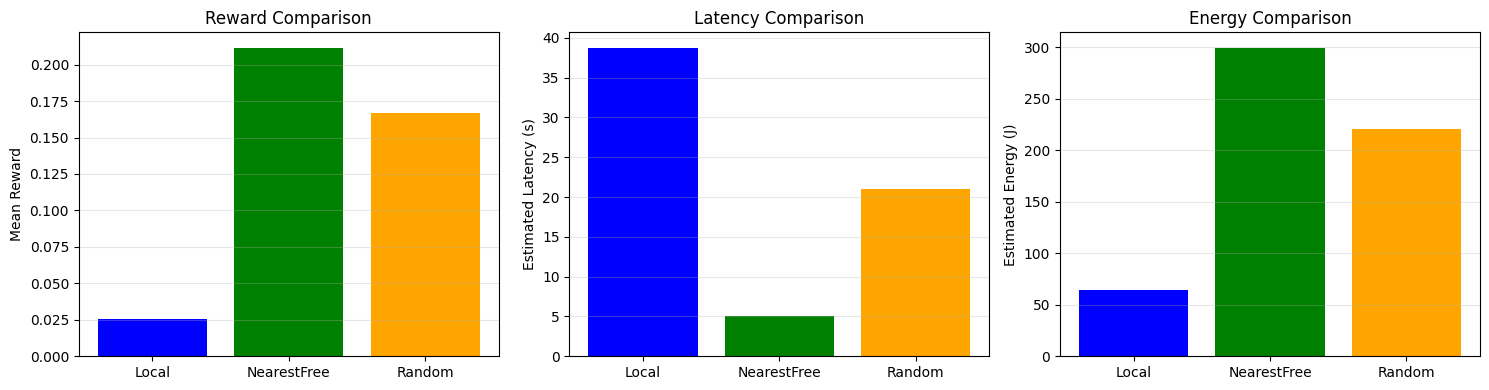


Plot saved as 'agent_comparison.png'


In [ ]:
import matplotlib.pyplot as plt

# Example: Compare agents by collecting metrics
def run_agent_with_metrics(agent_name, agent_func, num_episodes=1):
    """Run an agent and collect detailed metrics."""
    all_rewards = []
    all_latencies = []
    all_energies = []
    action_counts = {0: 0, 1: 0, 2: 0, 3: 0}
    
    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        episode_rewards = []
        
        while not done:
            if agent_name == "Random":
                action = env.action_space.sample()
            elif agent_name == "Local":
                action = 0
            elif agent_name == "NearestFree":
                action = agent_func(obs)
            else:
                action = 0
            
            obs, reward, done, info = env.step(action)
            
            if reward != 0.0:
                episode_rewards.append(float(reward))
                action_counts[action] += 1
                
                # Extract energy estimate from observation
                if len(obs) >= 14:
                    energy_local = float(obs[12]) * 100  # Denormalize
                    energy_offload = float(obs[13]) * 100
                    all_energies.append(energy_local if action == 0 else energy_offload)
                
                # Estimate latency from reward (inverse relationship)
                # reward = α * (1/latency) + β * (1/energy)
                est_latency = 1.0 / max(0.01, reward)
                all_latencies.append(est_latency)
        
        all_rewards.extend(episode_rewards)
    
    return {
        'name': agent_name,
        'mean_reward': np.mean(all_rewards) if all_rewards else 0,
        'mean_latency': np.mean(all_latencies) if all_latencies else 0,
        'mean_energy': np.mean(all_energies) if all_energies else 0,
        'action_counts': action_counts,
        'total_tasks': sum(action_counts.values())
    }

# Collect metrics for each agent
print("Collecting agent metrics...")
agents_metrics = [
    run_agent_with_metrics("Local", None, num_episodes=1),
    run_agent_with_metrics("NearestFree", pick_action, num_episodes=1),
    run_agent_with_metrics("Random", None, num_episodes=1),
]

# Display comparison table
print("\n=== Agent Comparison ===")
print(f"{'Agent':<15} {'Reward':<12} {'Est.Latency':<15} {'Est.Energy':<15} {'Tasks':<8}")
print("-" * 70)
for metrics in agents_metrics:
    print(f"{metrics['name']:<15} {metrics['mean_reward']:<12.6f} {metrics['mean_latency']:<15.3f} {metrics['mean_energy']:<15.3f} {metrics['total_tasks']:<8}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Reward comparison
axes[0].bar([m['name'] for m in agents_metrics], [m['mean_reward'] for m in agents_metrics], color=['blue', 'green', 'orange'])
axes[0].set_ylabel('Mean Reward')
axes[0].set_title('Reward Comparison')
axes[0].grid(axis='y', alpha=0.3)

# Latency comparison
axes[1].bar([m['name'] for m in agents_metrics], [m['mean_latency'] for m in agents_metrics], color=['blue', 'green', 'orange'])
axes[1].set_ylabel('Estimated Latency (s)')
axes[1].set_title('Latency Comparison')
axes[1].grid(axis='y', alpha=0.3)

# Energy comparison
axes[2].bar([m['name'] for m in agents_metrics], [m['mean_energy'] for m in agents_metrics], color=['blue', 'green', 'orange'])
axes[2].set_ylabel('Estimated Energy (J)')
axes[2].set_title('Energy Comparison')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

